# Import libs

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lendo dados

In [103]:
DATA = 'https://raw.githubusercontent.com/rafabandoni/world-cup-2026-predict/refs/heads/main/data/'

In [104]:
teams = pd.read_csv(
    "https://www.eloratings.net/en.teams.tsv",
    sep="\t",
    header=None,
    usecols=[0, 1],
    names=["team_code", "team_name"],
    engine="python"
)

print(teams.head())
teams_dict = teams.set_index('team_code').to_dict()['team_name']

  team_code    team_name
0        DN         Aden
1        AF  Afghanistan
2        AL      Albania
3        DZ      Algeria
4        AD      Andorra


In [105]:
elo = pd.read_parquet(DATA+'elo_historico.parquet')
elo = elo[elo['year'] >= 1925]
elo['team_name'] = elo['team_code'].map(teams_dict)
elo.drop('team_code', axis=1, inplace=True)
elo.head()

,local_rank,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,...,matches_neutral,wins,losses,draws,goals_for,goals_against,rank_change,rating_change,year,team_name
633,−,1,2012,1,2036,1,2010,3,1963,0.0,...,5,16,3,1,36,10,1.0,40.0,1925,Spain
634,−,2,1989,1,2026,3,1965,10,1855,2.0,...,13,72,45,36,271,193,1.0,35.0,1925,Argentina
635,−,3,1987,1,2104,4,1957,11,1781,0.0,...,0,86,23,29,390,161,1.0,75.0,1925,Scotland
636,−,4,1966,1,2065,5,1924,10,1827,-2.0,...,16,61,48,29,226,189,-3.0,-66.0,1925,Uruguay
637,−,5,1925,1,2213,2,2008,10,1867,0.0,...,4,141,35,33,747,243,0.0,23.0,1925,England


In [106]:
matches_hist = pd.read_csv(DATA+'world_cup_matches.csv')
matches_hist.head()

,ID,Year,Date,Stage,Home Team,Home Goals,Away Goals,Away Team,Win Conditions,Host Team
0,1,1930,1930-07-13,Group stage,France,4,1,Mexico,NaN,False
1,2,1930,1930-07-13,Group stage,United States,3,0,Belgium,NaN,False
2,3,1930,1930-07-14,Group stage,Yugoslavia,2,1,Brazil,NaN,False
3,4,1930,1930-07-14,Group stage,Romania,3,1,Peru,NaN,False
4,5,1930,1930-07-15,Group stage,Argentina,1,0,France,NaN,False


# Análise - Base de Elos

- Cada ano representa o "end-of-year" snapshot de elo para aquela seleção;
- O ano de 2026 é ytd no salvamento da base;
- Valores máximos e mínimos são pontos históricos, não variações no ano;
- Matches e goals são agregados ano a ano;

## Atribuição e licença:
- Fonte dos dados: **World Football Elo Ratings** (eloratings.net), por Kirill Bukin e Erik Gebhardt continuando o trabalho de Bob Runyan e Andrew Wallechinsky.

In [107]:
elo.isna().sum().sort_values(ascending=False)

rank_10y_change      2120
rating_10y_change    2120
rank_5y_change       1026
rating_5y_change     1026
rating_2y_change      399
rank_2y_change        399
rating_change         198
rank_change           198
rating_1y_change      198
rank_1y_change        198
rating_6m_change      103
rank_6m_change        103
rating_3m_change       42
rank_3m_change         42
global_rank             0
local_rank              0
rating_avg              0
rating_min              0
rank_avg                0
rating                  0
rating_max              0
rank_max                0
rank_min                0
matches_away            0
matches_home            0
matches_total           0
wins                    0
matches_neutral         0
losses                  0
draws                   0
goals_against           0
goals_for               0
year                    0
team_name               0
dtype: int64

<Axes: >

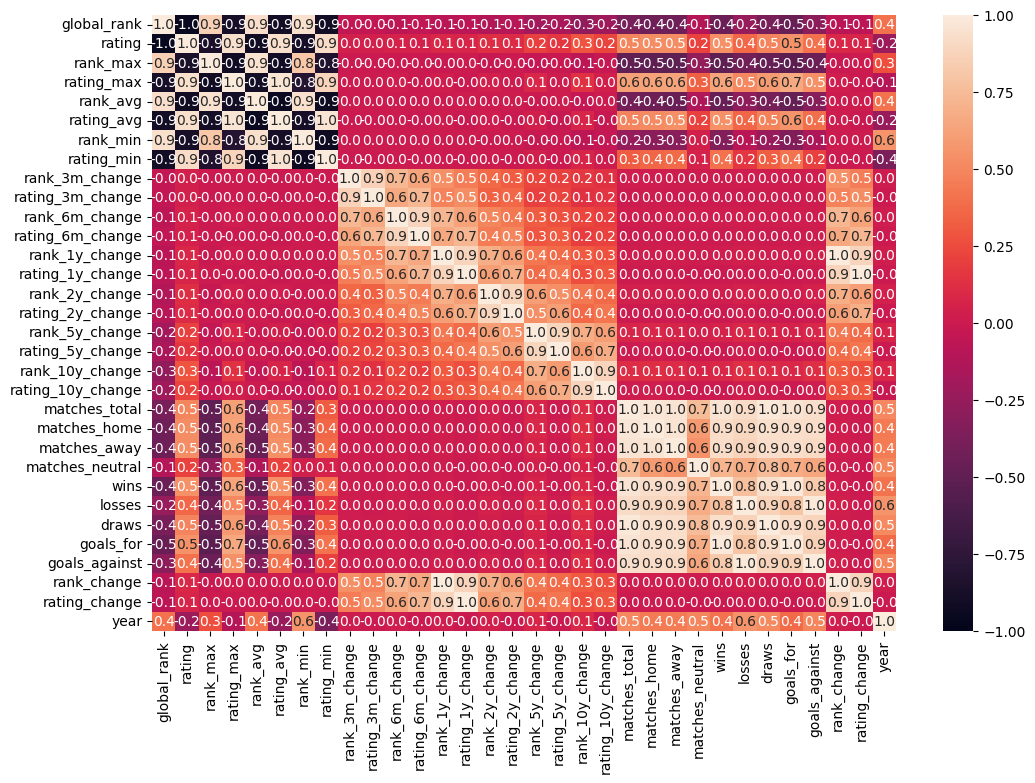

In [108]:
plt.figure(figsize=(12,8))
sns.heatmap(
    elo.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".1f"
)

In [109]:
elo_br = elo[elo['team_name']=='Brazil']
elo_br.head()

,local_rank,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,...,matches_neutral,wins,losses,draws,goals_for,goals_against,rank_change,rating_change,year,team_name
638,−,6,1923,6,1923,8,1872,14,1805,4.0,...,13,16,15,8,63,58,1.0,54.0,1925,Brazil
694,−,5,1923,5,1923,8,1876,14,1805,0.0,...,13,16,15,8,63,58,1.0,0.0,1926,Brazil
755,−,6,1923,5,1923,8,1879,14,1805,0.0,...,13,16,15,8,63,58,-1.0,0.0,1927,Brazil
817,−,7,1923,5,1923,8,1882,14,1805,-1.0,...,13,16,15,8,63,58,-1.0,0.0,1928,Brazil
880,−,7,1923,5,1923,8,1885,14,1805,-2.0,...,13,16,15,8,63,58,0.0,0.0,1929,Brazil


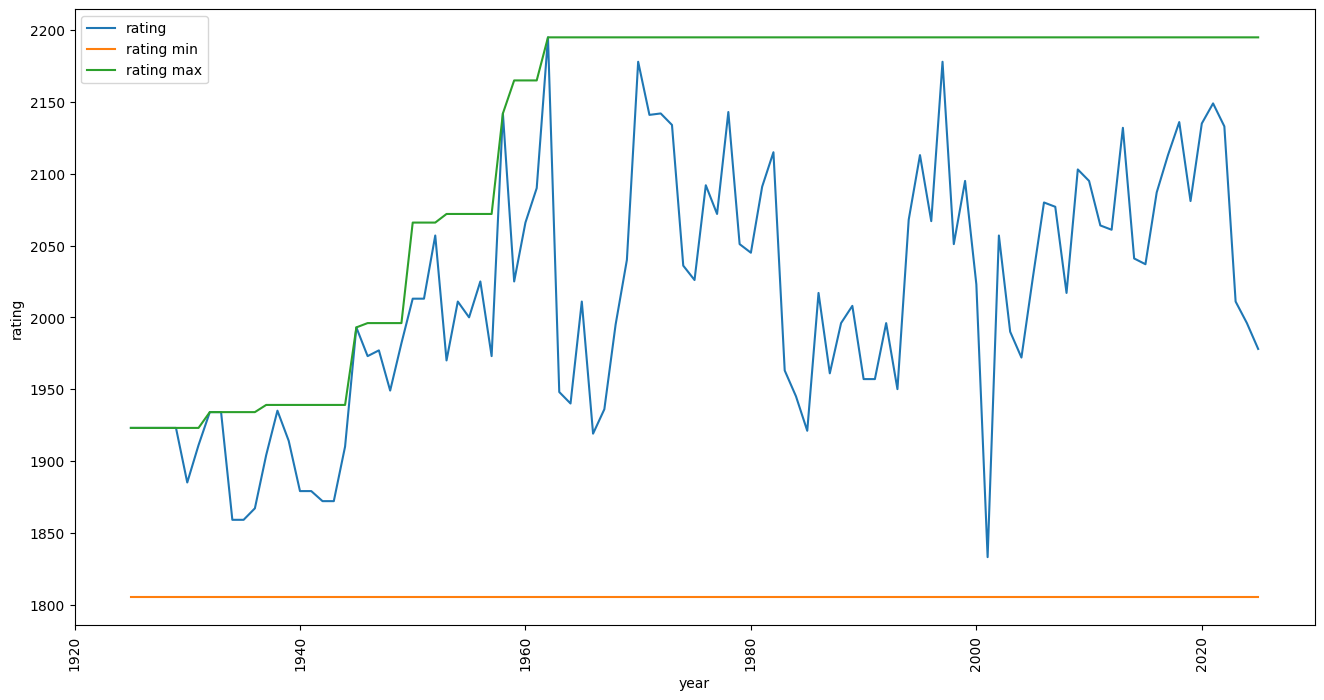

In [110]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating',
    label='rating'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating_min',
    label='rating min'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating_max',
    label='rating max'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

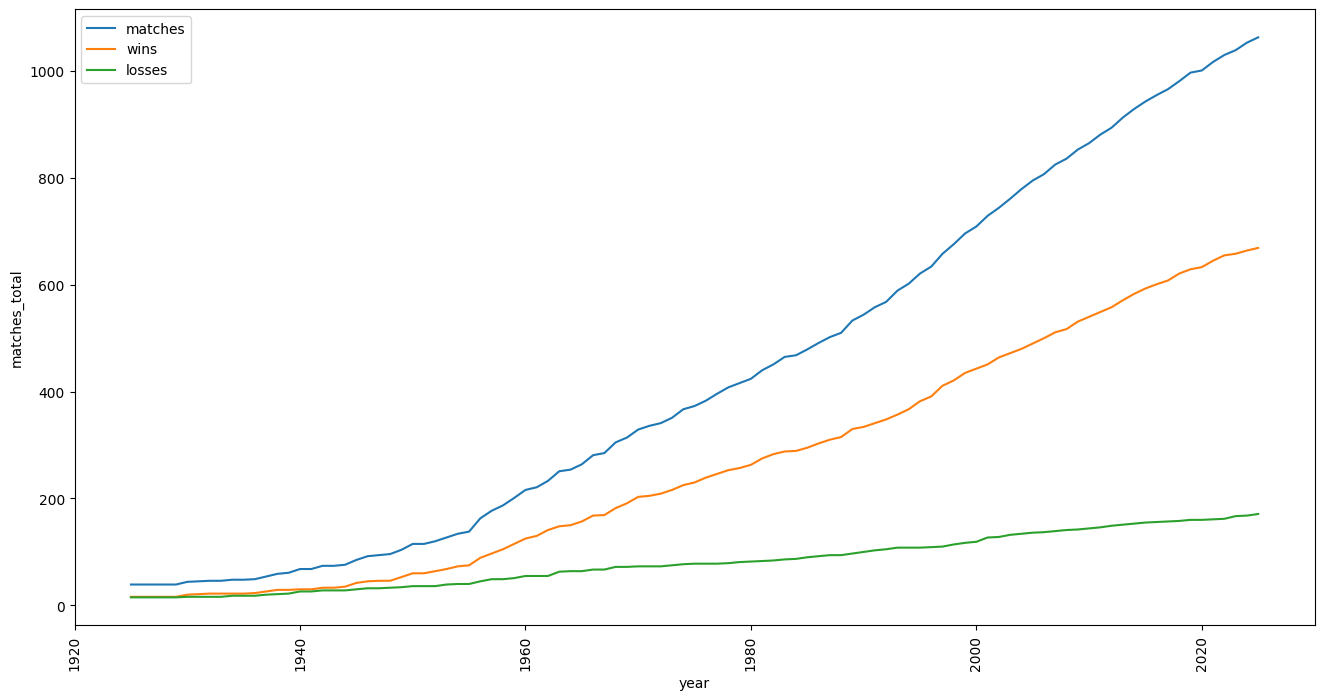

In [111]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='matches_total',
    label='matches'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='wins',
    label='wins'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='losses',
    label='losses'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

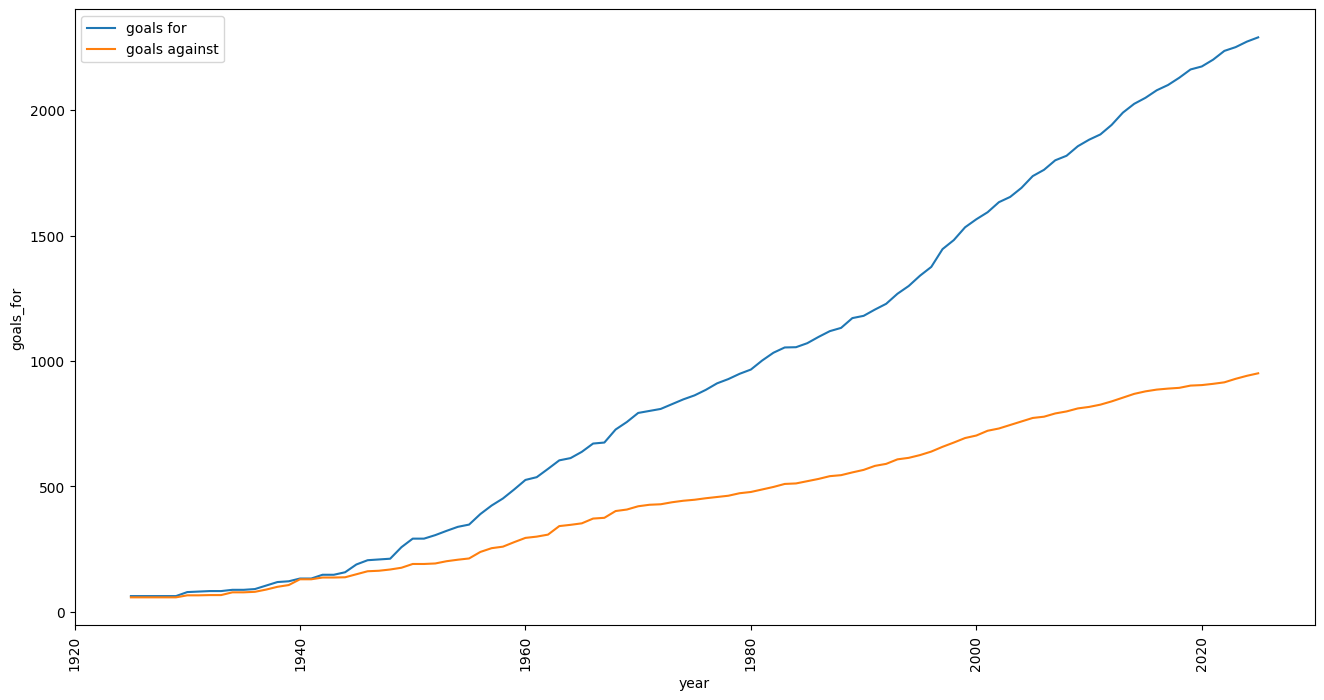

In [112]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='goals_for',
    label='goals for'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='goals_against',
    label='goals against'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

## Criando base para feature engineering

In [113]:
elo

,local_rank,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,...,matches_neutral,wins,losses,draws,goals_for,goals_against,rank_change,rating_change,year,team_name
633,−,1,2012,1,2036,1,2010,3,1963,0.0,...,5,16,3,1,36,10,1.0,40.0,1925,Spain
634,−,2,1989,1,2026,3,1965,10,1855,2.0,...,13,72,45,36,271,193,1.0,35.0,1925,Argentina
635,−,3,1987,1,2104,4,1957,11,1781,0.0,...,0,86,23,29,390,161,1.0,75.0,1925,Scotland
636,−,4,1966,1,2065,5,1924,10,1827,-2.0,...,16,61,48,29,226,189,-3.0,-66.0,1925,Uruguay
637,−,5,1925,1,2213,2,2008,10,1867,0.0,...,4,141,35,33,747,243,0.0,23.0,1925,England
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17910,−,240,496,194,500,225,496,240,496,0.0,...,2,0,2,0,0,33,-1.0,0.0,2025,Niue
17911,−,241,432,214,682,233,513,243,396,0.0,...,18,5,28,3,43,153,-1.0,0.0,2025,Northern Mariana Islands
17912,−,242,422,222,487,234,423,242,386,0.0,...,0,2,7,1,8,29,-1.0,0.0,2025,Cocos Islands
17913,−,243,402,225,442,237,402,243,402,0.0,...,0,0,2,0,3,27,-1.0,0.0,2025,Palau


In [114]:
# O elo criado no ultimo dia do ano deve ser aplicado no ano seguinte
elo['year_applied'] = elo['year'] + 1

# Criando valores anuais de match e goal
elo = elo.sort_values(['team_name', 'year'])
agg_cols = [
    'matches_total',
    'wins',
    'losses',
    'draws',
    'goals_for',
    'goals_against',
]

for col in agg_cols:
    elo[f'{col}_year'] = (
        elo
        .groupby('team_name')[col]
        .diff()
        .fillna(elo[col])
    )

elo.drop([
    'local_rank',
    'year', # vou deixar só year_applied pra usar year-1 no modelo
], axis=1, inplace=True)

elo = elo.fillna(0)

display(elo.head())
display(elo.tail())

,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,rating_3m_change,...,rank_change,rating_change,team_name,year_applied,matches_total_year,wins_year,losses_year,draws_year,goals_for_year,goals_against_year
4372,110,1302,110,1302,110,1302,110,1302,0.0,0.0,...,0.0,0.0,Aden,1962,1.0,1.0,0.0,0.0,4.0,2.0
4527,110,1302,110,1302,111,1302,111,1302,0.0,0.0,...,0.0,0.0,Aden,1963,0.0,0.0,0.0,0.0,0.0,0.0
4684,111,1302,109,1302,110,1302,111,1302,0.0,0.0,...,-1.0,0.0,Aden,1964,0.0,0.0,0.0,0.0,0.0,0.0
4845,113,1302,109,1302,111,1302,114,1302,1.0,0.0,...,-2.0,0.0,Aden,1965,0.0,0.0,0.0,0.0,0.0,0.0
5018,126,1249,109,1302,113,1298,128,1249,-1.0,0.0,...,-13.0,-53.0,Aden,1966,4.0,0.0,4.0,0.0,3.0,25.0


,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,rating_3m_change,...,rank_change,rating_change,team_name,year_applied,matches_total_year,wins_year,losses_year,draws_year,goals_for_year,goals_against_year
16828,130,1311,43,1574,76,1468,131,1311,-7.0,-29.0,...,-30.0,-106.0,Zimbabwe,2022,12.0,1.0,7.0,4.0,6.0,15.0
17073,132,1313,43,1574,76,1466,138,1278,-1.0,0.0,...,-2.0,2.0,Zimbabwe,2023,4.0,1.0,2.0,1.0,3.0,4.0
17311,127,1334,43,1574,77,1465,138,1278,0.0,16.0,...,5.0,21.0,Zimbabwe,2024,4.0,0.0,0.0,4.0,4.0,4.0
17543,116,1377,43,1574,78,1463,146,1278,13.0,44.0,...,11.0,43.0,Zimbabwe,2025,13.0,4.0,5.0,4.0,13.0,16.0
17790,120,1342,43,1574,78,1462,146,1278,-1.0,-13.0,...,-4.0,-35.0,Zimbabwe,2026,16.0,2.0,8.0,6.0,14.0,22.0


In [115]:
# envia o arquivo parquet para a pasta de dados
elo.to_parquet('../data/elo_featured.parquet')

# Criação de treino e teste

In [116]:
matches_hist.drop([
    'ID',
    'Host Team',
    'Stage'
], axis=1, inplace=True)

In [117]:
home_winner = []
for idx, row in matches_hist.iterrows():
    if row['Home Goals'] > row['Away Goals']:
        home_winner.append(1)
    elif row['Home Goals'] < row['Away Goals']:
        home_winner.append(0)
    else:
        if pd.isna(row['Win Conditions']):
            home_winner.append(0)
        elif row['Win Conditions'].split(' ')[0] == row['Home Team']:
            home_winner.append(1)
        else:
            home_winner.append(0)
        # home_winner.append(2) # tratar empates
matches_hist['home_winner'] = home_winner

In [118]:
matches_hist.drop('Win Conditions', axis=1, inplace=True)

In [119]:
matches_hist.tail()

,Year,Date,Home Team,Home Goals,Away Goals,Away Team,home_winner
895,2018,2018-07-07,Russia,2,2,Croatia,0
896,2018,2018-07-10,France,1,0,Belgium,1
897,2018,2018-07-11,Croatia,2,1,England,1
898,2018,2018-07-14,Belgium,2,0,England,1
899,2018,2018-07-15,France,4,2,Croatia,1


In [120]:
matches_hist[matches_hist['Year'] == 2018].to_parquet('../data/valid.parquet')
matches_hist[matches_hist['Year'] < 2018].to_parquet('../data/train.parquet')